In [128]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [129]:
df = pd.read_csv('datasets/final_dataset.csv')
df.drop(columns=['Unnamed: 0'])

,encounter_id,days_in_hospital,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,metformin,glipizide,glyburide,...,drugs_other,discharge_disposition_other,discharge_disposition_home,admission_other,admission_urgent,admission_elective,no_test,norm_result_test,high_result_test_and_change_meds,high_result_test_but_no_change_meds
0,2278392,1,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
1,149190,3,0,18,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
2,64410,2,5,13,2,0,1,0,1,0,...,0,0,1,0,1,0,1,0,0,0
3,500364,2,1,16,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
4,16680,1,0,8,0,0,0,0,1,0,...,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69965,443842016,9,2,33,0,0,0,0,0,1,...,0,0,1,0,1,0,0,0,1,0
69966,443842022,14,6,26,0,1,0,0,1,0,...,0,0,1,0,1,0,0,0,1,0
69967,443842070,2,6,17,1,1,1,0,0,0,...,0,0,1,0,1,0,1,0,0,0
69968,443842340,5,1,22,0,1,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0


In [130]:
df2 = pd.read_csv('datasets/data_severity.csv')
df = pd.merge(df, df2, on='encounter_id', how='left')

In [131]:
df.columns

Index(['Unnamed: 0_x', 'encounter_id', 'days_in_hospital', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'metformin', 'glipizide', 'glyburide', 'insulin',
       'diabetesMed', 'retention', 'race_other', 'race_african_american',
       'race_caucasian', 'race_missing', 'sex_female', 'sex_male', '30-60y',
       '60y or more', 'less than 30y', 'drugs_other',
       'discharge_disposition_other', 'discharge_disposition_home',
       'admission_other', 'admission_urgent', 'admission_elective', 'no_test',
       'norm_result_test', 'high_result_test_and_change_meds',
       'high_result_test_but_no_change_meds', 'Unnamed: 0_y', 'severity'],
      dtype='object')

**Гипотеза:**

У пациентов, с проведенным HbA1C тестом, своевременная коррекция терапии  является независимым фактором, снижающим риск ранней повторной госпитализации, даже после учета влияния возраста пациента, тяжести состояния  и типа поступления. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ

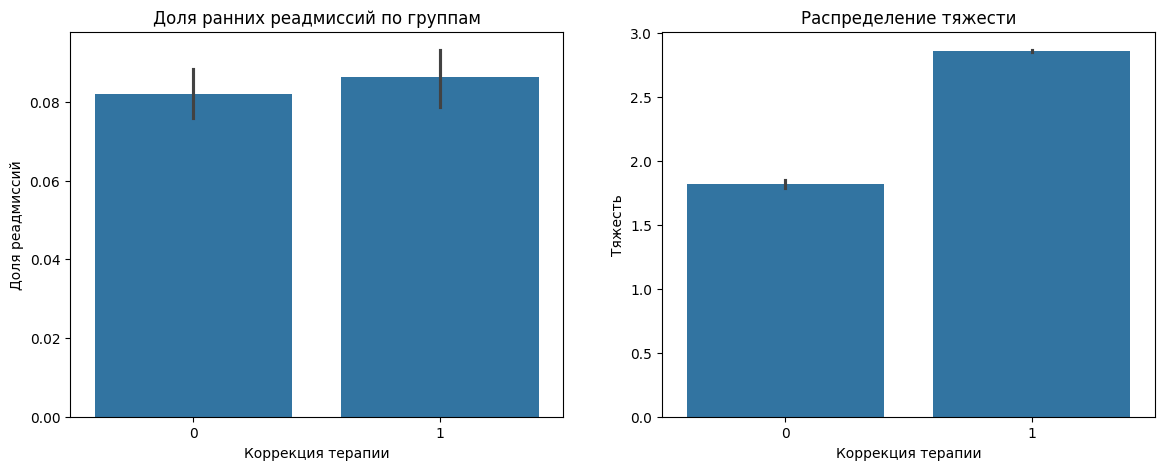

                           Logit Regression Results                           
Dep. Variable:              retention   No. Observations:                12845
Model:                          Logit   Df Residuals:                    12839
Method:                           MLE   Df Model:                            5
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                0.007239
Time:                        18:48:45   Log-Likelihood:                -3675.8
converged:                       True   LL-Null:                       -3702.6
Covariance Type:            nonrobust   LLR p-value:                 2.527e-10
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -2.6347      0.106    -24.878      0.000      -2.842      -2.427
high_result_test_and_change_meds     0.0578      0.072      0.798

In [132]:
import statsmodels.api as sm
df_ml = df[(df['no_test'] == 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Барплот для доли реадмиссий
sns.barplot(x='high_result_test_and_change_meds', y='retention', data=df_ml, ax=axes[0])
axes[0].set_title('Доля ранних реадмиссий по группам')
axes[0].set_xlabel('Коррекция терапии')
axes[0].set_ylabel('Доля реадмиссий')

#Barplot для тяжести 
sns.barplot(x='high_result_test_and_change_meds', y='severity', data=df_ml, ax=axes[1])
axes[1].set_title('Распределение тяжести')
axes[1].set_xlabel('Коррекция терапии')
axes[1].set_ylabel('Тяжесть')
plt.show()

X = df_ml[[
    'high_result_test_and_change_meds',
    '60y or more',
    'less than 30y',
    'severity',
    'admission_urgent'
]]

X = sm.add_constant(X, has_constant='add')
y = df_ml['retention']

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=False, maxiter=100)

print(result.summary())

**Обобщающая модель:**

In [133]:
df.columns

Index(['Unnamed: 0_x', 'encounter_id', 'days_in_hospital', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'metformin', 'glipizide', 'glyburide', 'insulin',
       'diabetesMed', 'retention', 'race_other', 'race_african_american',
       'race_caucasian', 'race_missing', 'sex_female', 'sex_male', '30-60y',
       '60y or more', 'less than 30y', 'drugs_other',
       'discharge_disposition_other', 'discharge_disposition_home',
       'admission_other', 'admission_urgent', 'admission_elective', 'no_test',
       'norm_result_test', 'high_result_test_and_change_meds',
       'high_result_test_but_no_change_meds', 'Unnamed: 0_y', 'severity'],
      dtype='object')

In [134]:
import statsmodels.api as sm

df_explain = df.copy()

features = [
    '60y or more', 'less than 30y',
    'high_result_test_and_change_meds',
    'high_result_test_but_no_change_meds',
    'norm_result_test', 'no_test',
    'num_medications', 'num_procedures',
    'number_emergency', 'number_inpatient', 'number_outpatient',
    'admission_urgent', 'admission_elective',
    'sex_male',
    'race_african_american', 'race_caucasian',
    'insulin', 'metformin',
    'severity'
]

X = sm.add_constant(df_explain[features])
y = df_explain['retention']


In [135]:
model = sm.Logit(y, X).fit(disp=False)

In [136]:
results = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params,
    'p_value': model.pvalues,
})

significant = results.query("p_value < 0.01 and feature != 'const'")


print("Значимые признаки")
print(significant[['feature', 'p_value']].round(3).to_string(index=False))

Значимые признаки
              feature  p_value
          60y or more    0.000
      num_medications    0.000
     number_emergency    0.001
     number_inpatient    0.000
race_african_american    0.010
       race_caucasian    0.008
            metformin    0.004
             severity    0.000


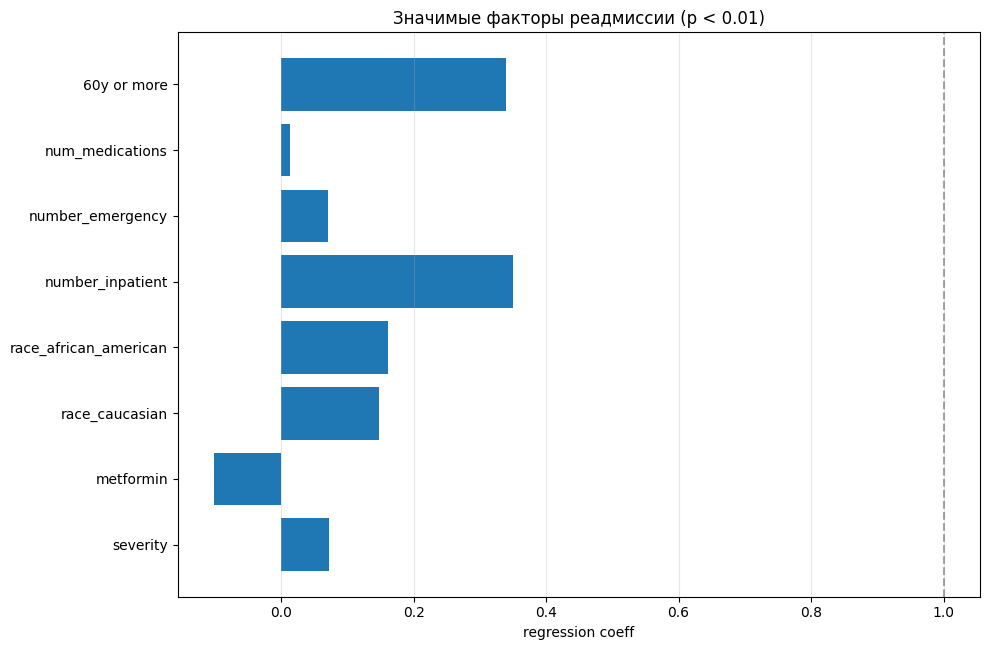

In [137]:
plt.figure(figsize=(10, 0.45 * len(significant) + 3))

plt.axvline(1, linestyle='--', color='gray', alpha=0.7)
plt.barh(
    significant['feature'],
    significant['coef']
)

plt.xlabel('regression coeff')
plt.title('Значимые факторы реадмиссии (p < 0.01)')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

important_features = [
    '60y or more',
    'num_medications',
    'number_emergency',
    'number_inpatient',
    'race_african_american',
    'race_caucasian',
    'diabetesMed',
    'metformin'
]

df_explain = df_explain[df_explain['admission_urgent'] == 1]
X = df_explain[important_features].copy()
y = df_explain['retention']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

              precision    recall  f1-score   support

           0     0.9222    0.5925    0.7215     10967
           1     0.1099    0.5018    0.1804      1100

    accuracy                         0.5842     12067
   macro avg     0.5161    0.5472    0.4509     12067
weighted avg     0.8482    0.5842    0.6722     12067

Accuracy: 0.5842


Улучшаем

In [139]:
from sklearn.metrics import precision_recall_curve
y_proba = logreg.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

pr_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall': recall[:-1]
})
pr_df['f1'] = (2 * pr_df['precision'] * pr_df['recall'])/(pr_df['precision'] + pr_df['recall'])

best_f1 = pr_df.sort_values('f1', ascending=False).iloc[0]
target_recall = 0.8

best_recall_threshold = pr_df[pr_df['recall'] >= target_recall].sort_values('precision', ascending=False).iloc[0]

threshold = best_recall_threshold['threshold']

y_pred_custom = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom, digits=4))

              precision    recall  f1-score   support

           0     0.9376    0.3014    0.4561     10967
           1     0.1030    0.8000    0.1825      1100

    accuracy                         0.3468     12067
   macro avg     0.5203    0.5507    0.3193     12067
weighted avg     0.8615    0.3468    0.4312     12067



После оптимизации порога классификации модель демонстрирует
способность выявлять ~70% пациентов с риском реадмиссии.
Несмотря на снижение accuracy, уменьшение количества ложно
отрицательных прогнозов делает модель более полезной
для клинического применения, где приоритетом является
минимизация пропусков реадмиссии.
